## **3주차 과제 - NLP _ 25기 이유민**

안녕하세요:) NLP 세션 과제를 맡은 24기 김승현입니다.

이번 과제는 이론 문제 1개와 실습 예제 1개로 구성되어 있습니다. **(GPU를 사용하세요!!)**

실습 파트에서는 고전적인 **TF-IDF 기반 모델**과 최신 **BERT(DistilBERT) 모델**을 직접 구현하며 성능 차이를 대조해 보는 데 중점을 두었습니다.

각 단계별 코드의 빈칸을 채워 실행해 보시길 바라며, 과제에 대해 궁금한 점이 생기시면 언제든 편하게 연락해 주세요!


# **Q1_이론문제**

**[문제]**

기존의 RNN은 문장을 순차적으로 처리하는 구조적 특성으로 인해 장기 의존성(Long-term dependency) 문제가 존재했다.

Transformer는 Self-Attention을 도입하여 이러한 한계를 극복하였다.

이때, **Self-Attention의 핵심 아이디어가 무엇인지 설명하고 RNN의 한계를 어떻게 해결하는지 서술하시오.**

=> RNN은 데이터를 순차적으로 처리하는 구조적 한계로 인해 문장이 길어질수록 앞부분의 정보가 소실되거나 왜곡되는 장기 의존성(Long-term dependency) 문제를 안고 있다. Transformer는 이러한 물리적 거리의 제약을 극복하기 위해 모든 단어 쌍 간의 관계를 동시에 계산하는 Self-Attention 매커니즘을 핵심 아이디어로 도입하였다. Self-Attention은 특정 단어를 처리할 때 문장 내의 다른 모든 단어와 얼마나 관련이 있는지 가중치를 동적으로 부여하여 문맥적 의미를 파악하는 방식이다.  이를 통해 Transformer는 RNN처럼 순차적으로 정보를 전달하며 감쇄되는 과정 없이, 문장 내 어떤 위치에 있는 단어라도 직접적으로 연결하여 정보를 참조할 수 있게 되었다. 결과적으로 입력 데이터 전체를 한꺼번에 병렬로 처리함으로써 초기 정보의 손실을 방지하고, 멀리 떨어진 단어 사이의 복잡한 문법적 관계까지 정확하게 포착하여 RNN의 고질적인 한계를 효과적으로 해결하였다.

# **Q2_실습문제**

NLP의 대표적인 예제인 영화 리뷰 데이터를 활용해 긍정/부정 감성 분석을 진행합니다.

텍스트 전처리부터 워드클라우드 시각화, 그리고 두 가지 모델(TF-IDF, BERT)의 구현까지 빈칸을 채우며 실습을 완료해 주세요.

참고) imdb 영화 리뷰 데이터
  - train: 학습용 데이터 25,000개
  - test: 검증용 데이터 25,000개
  - features: text(리뷰 내용), label(긍정/부정)


### Import Packages

In [1]:
!pip -q install datasets transformers evaluate accelerate scikit-learn wordcloud matplotlib pandas numpy

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.32.0 requires protobuf<5,>=3.20, but you have protobuf 6.33.2 which is incompatible.


In [2]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

### Data Load

In [3]:
from datasets import load_dataset
ds = load_dataset("imdb")
ds["train"].to_pandas().head()

README.md: 0.00B [00:00, ?B/s]

C:\Users\yoomi\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\yoomi\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [4]:
# train data + test data -> df_all
label_names = ds["train"].features["label"].names
all_texts = list(ds["train"]["text"]) + list(ds["test"]["text"])
all_labels = list(ds["train"]["label"]) + list(ds["test"]["label"])

df_all = pd.DataFrame({"text": all_texts, "label": all_labels})
df_all["label_name"] = df_all["label"].map(lambda x: label_names[x])
df_all["label_name"].value_counts()

label_name
neg    25000
pos    25000
Name: count, dtype: int64

### Data Preprocessing


Text preprocessing 단계 중 정규화(Normalization) 중심으로 전처리를 수행합니다.

토큰화는 BERT 내부 토크나이저를 사용하므로, 전처리 단계에서는 별도로 수행하지 않습니다.

In [5]:
def clean_text(t: str) -> str:
    # 1. HTML 태그 제거(웹 데이터에 섞인 <br/> 태그 등을 공백으로 치환)
    t = t.replace("<br />", " ")
    # 2. 정규화: 대소문자를 소문자로 통일
    t = t.lower()
    # 3. 정규화: 특수문자 제거
    t = re.sub(r"[^a-z\s]", " ", t)
    # 4. 불필요한 공백 제거
    t = re.sub(r"\s+", " ", t).strip()
    return t

# 전처리 함수 적용
df_all["clean"] = df_all["text"].map(clean_text)
df_all[["label_name", "text", "clean"]].head(5)

,label_name,text,clean
0,neg,I rented I AM CURIOUS-YELLOW from my video sto...,i rented i am curious yellow from my video sto...
1,neg,"""I Am Curious: Yellow"" is a risible and preten...",i am curious yellow is a risible and pretentio...
2,neg,If only to avoid making this type of film in t...,if only to avoid making this type of film in t...
3,neg,This film was probably inspired by Godard's Ma...,this film was probably inspired by godard s ma...
4,neg,"Oh, brother...after hearing about this ridicul...",oh brother after hearing about this ridiculous...


### WordCloud


긍정/부정 리뷰를 각각 샘플링하여 워드클라우드를 생성하면 자주 등장하는 단어를 시각적으로 비교할 수 있습니다.

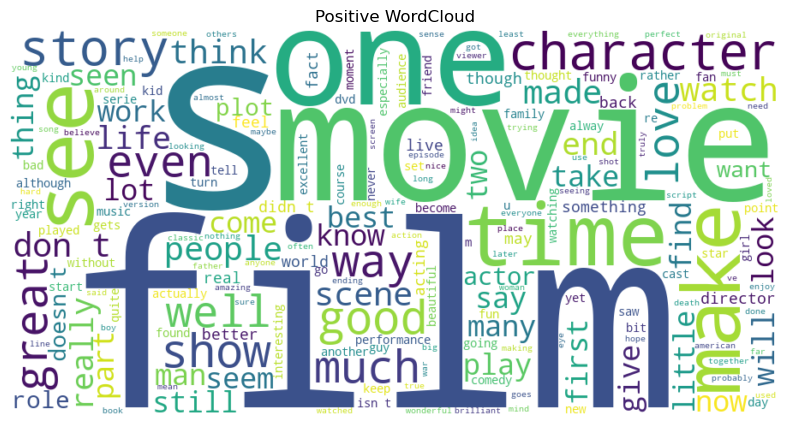

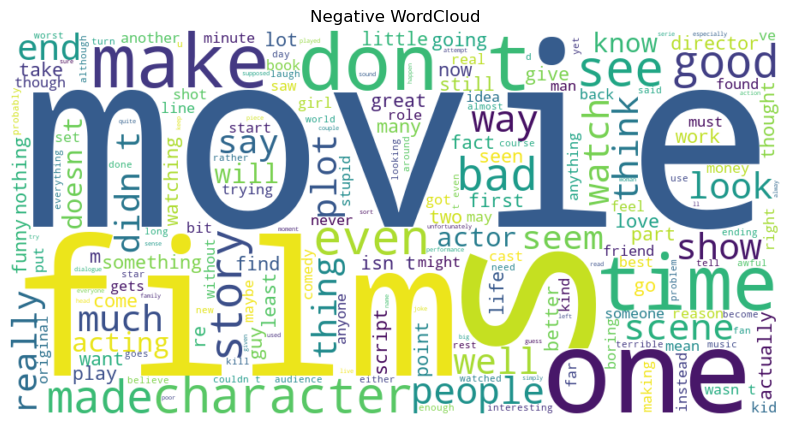

In [6]:
SEED = 42

# 긍정/부정 리뷰 샘플링 후 하나의 문자열로 결합
pos_text = " ".join(df_all.loc[df_all["label_name"]=="pos", "clean"].sample(20000, random_state=SEED))
neg_text = " ".join(df_all.loc[df_all["label_name"]=="neg", "clean"].sample(20000, random_state=SEED))

# WordCloud 생성
wc_pos = WordCloud(width=900, height=450, background_color="white", max_words=200).generate(pos_text)
wc_neg = WordCloud(width=900, height=450, background_color="white", max_words=200).generate(neg_text)

# WordCloud 시각화
plt.figure(figsize=(14,5))
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Positive WordCloud")
plt.show()

plt.figure(figsize=(14,5))
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Negative WordCloud")
plt.show()

## **Model(1): TF-IDF + Logistic Regression**


첫번째 모델로는 딥러닝이 등장하기 전부터 자연어 처리 분야에서 널리 쓰여온 전통적인 머신러닝 방식을 실습합니다.

단어의 출현 빈도를 수치화하는 TF-IDF 기법과 선형 분류 알고리즘인 로지스틱 회귀를 결합하여 감성 분석 모델을 구현합니다.

In [7]:
# 데이터 프레임 구성
train_df = pd.DataFrame(ds["train"])
test_df  = pd.DataFrame(ds["test"])

# Text Preprocessing 수행 (clean_text 함수 활용)
train_df["clean"] = train_df["text"].map(clean_text)
test_df["clean"]  = test_df["text"].map(clean_text)

X_train, y_train = train_df["clean"].values, train_df["label"].values
X_test,  y_test  = test_df["clean"].values,  test_df["label"].values

In [8]:
# TF-IDF 설정
tfidf = TfidfVectorizer(
    # 중요도 상위 30,000개의 단어만 사용
    max_features=30000,
    # 1-gram과 2-gram 모두 반영
    ngram_range=(1,2),
    # 최소 2개 이상의 출현 단어
    min_df=2
)

# 벡터화 적용
Xtr_tfidf = tfidf.fit_transform(X_train)
Xte_tfidf = tfidf.transform(X_test)
print("TF-IDF train shape:", Xtr_tfidf.shape)
print("TF-IDF test  shape:", Xte_tfidf.shape)
print("Vocab size:", len(tfidf.vocabulary_))

TF-IDF train shape: (25000, 30000)
TF-IDF test  shape: (25000, 30000)
Vocab size: 30000


In [9]:
## 예시) 샘플 문서의 TF-IDF 상위 단어 확인
feature_names = np.array(tfidf.get_feature_names_out())

sample_idx = 0                  # 리뷰 인덱스 -> 숫자 바꿔가면서 확인해보기 !!
row = Xtr_tfidf[sample_idx]    # 해당 리뷰의 TF-IDF 벡터
topk = 15                      # 상위 15개 단어 확인

sorted_idx = np.argsort(row.data)[::-1][:topk]
top_features = row.indices[sorted_idx]
top_scores = row.data[sorted_idx]

print("샘플 원문(전처리 후):")
print(X_train[sample_idx][:400], "...\n")

print(f"Top {topk} TF-IDF features:")
for f, s in zip(feature_names[top_features], top_scores):
    print(f"{f:20s}  {s:.4f}")

샘플 원문(전처리 후):
i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at first it was seized by u s customs if it ever tried to enter this country therefore being a fan of films considered controversial i really had to see this for myself the plot is centered around a young swedish drama student named lena who wants to le ...

Top 15 TF-IDF features:
swedish               0.1990
sex                   0.1946
yellow                0.1928
curious               0.1633
pornographic          0.1447
and nudity            0.1415
shown                 0.1262
shown in              0.1156
sex and               0.1151
in                    0.1088
issues                0.1014
am                    0.0979
the                   0.0974
considered            0.0969
nudity                0.0947


In [10]:
# 로지스틱 회귀모델 학습
lr = LogisticRegression(max_iter=2000, n_jobs=None)
lr.fit(Xtr_tfidf, y_train)

LogisticRegression(max_iter=2000)

In [11]:
# 로지스틱 회귀모델 결과
pred_lr = lr.predict(Xte_tfidf)
print("\nClassification Report:\n", classification_report(y_test, pred_lr, target_names=label_names))


Classification Report:
               precision    recall  f1-score   support

         neg       0.90      0.89      0.90     12500
         pos       0.89      0.90      0.90     12500

    accuracy                           0.90     25000
   macro avg       0.90      0.90      0.90     25000
weighted avg       0.90      0.90      0.90     25000



In [12]:
# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_lr))

Confusion Matrix:
 [[11163  1337]
 [ 1260 11240]]


In [13]:
## 추가) 회귀 계수 기반 감성 기여 단어 확인
coef = lr.coef_.ravel()
top_pos_idx = np.argsort(coef)[-20:][::-1]
top_neg_idx = np.argsort(coef)[:20]

print("긍정에 기여 큰 단어(상위 20):")
print(feature_names[top_pos_idx])

print("\n부정에 기여 큰 단어(상위 20):")
print(feature_names[top_neg_idx])

긍정에 기여 큰 단어(상위 20):
['great' 'excellent' 'wonderful' 'perfect' 'amazing' 'the best' 'best'
 'fun' 'today' 'love' 'loved' 'and' 'well' 'brilliant' 'favorite' 'superb'
 'enjoyed' 'beautiful' 'bit' 'highly']

부정에 기여 큰 단어(상위 20):
['bad' 'worst' 'awful' 'the worst' 'boring' 'poor' 'waste' 'terrible' 'no'
 'nothing' 'worse' 'dull' 'horrible' 'poorly' 'stupid' 'unfortunately'
 'annoying' 'script' 'ridiculous' 'even']


## **Model(2): BERT**

두번째로 딥러닝 기반의 사전학습 언어모델인 BERT를 활용하여 감성 분류를 수행합니다.

Self-Attention 기반의 Transformer 구조를 통해 문맥 정보를 양방향으로 반영하며 사전학습된 DistilBERT 모델을 파인튜닝하여 분류 성능을 향상시킵니다.

**아래 코드의 빈칸을 채워 모델을 완성한 후, 하이퍼파라미터를 조정하며 성능 변화를 비교해 보세요 !!**


In [14]:
# 사전학습 DistilBERT(BERT의 경량화 버전) 모델 설정
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 배치 단위 토큰화
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        max_length=300,         # 최대 토큰 길이
        truncation=True,        # 최대 길이 초과 시 잘라내기
        padding="max_length"    # 최대 길이 기준 패딩
    )

# 토큰화 적용
ds_tok = ds.map(tokenize_batch, batched=True)
# trainer에서 원본 리뷰 컬럼 제거
ds_tok = ds_tok.remove_columns(["text"])
# label → labels 컬럼명 변경 (Trainer 호환)
ds_tok = ds_tok.rename_column("label", "labels")
# PyTorch 텐서 형식 변환
ds_tok.set_format("torch")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

C:\Users\yoomi\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\yoomi\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [16]:
SEED = 42
from transformers import DistilBertForSequenceClassification

# DistilBERT 모델 로드
model_bert = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

# DistilBERT 모델 로드
model_bert = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 평가 지표 로드
metric_acc = evaluate.load("accuracy")
metric_f1  = evaluate.load("f1")

# 평가 함수 정의
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": metric_acc.compute(predictions=preds, references=labels)["accuracy"],
        "f1": metric_f1.compute(predictions=preds, references=labels, average="binary")["f1"]
    }

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
# 학습 하이퍼파라미터 설정 -> 파라미터 조절하기 !!
training_args = TrainingArguments(
    output_dir="./imdb_distilbert",  # 모델 저장 경로
    eval_strategy="steps",           # 평가 수행 기준 (epoch or steps)
    save_strategy="no",               # 체크포인트 저장 여부
    logging_strategy="steps",        # 로그 출력 기준 (epoch or steps)
    logging_steps=200,               # 로그 출력 간격 (step 단위)
    per_device_train_batch_size=32,  # 학습 배치 크기
    per_device_eval_batch_size=64,   # 평가 배치 크기
    num_train_epochs=1,              # 학습 epoch 수 (1에폭하는데 대략 12분 소요)
    learning_rate=2e-5,
    weight_decay=0.01,
    seed=SEED,
    report_to="none"
)

# Trainer 객체 생성
trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["test"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

# 모델 학습
trainer.train()

C:\Users\yoomi\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss


KeyboardInterrupt: 

In [18]:
# 모델 결과
eval_bert = trainer.evaluate()
eval_bert

KeyboardInterrupt: 

In [19]:
# Confusion Matrix
pred_out = trainer.predict(ds_tok["test"])
pred_bert = np.argmax(pred_out.predictions, axis=-1)
cm_bert = confusion_matrix(ds_tok["test"]["labels"], pred_bert)
print("BERT Confusion Matrix:\n", cm_bert)

KeyboardInterrupt: 

## **Results**

두 모델의 정확도를 비교하고 성능차이를 확인합니다.

In [20]:
# 모델별 정확도 계산
acc_lr = accuracy_score(y_test, pred_lr)
acc_bert = (pred_bert == np.array(ds["test"]["label"])).mean()
print(f"TF-IDF + LR Accuracy : {acc_lr:.4f}")
print(f"BERT Accuracy        : {acc_bert:.4f}")

NameError: name 'pred_bert' is not defined

In [21]:
# 모델 예측 결과 비교용 데이터프레임 생성
compare_df = pd.DataFrame({
    "text": test_df["text"],
    "gold": test_df["label"].map(lambda x: label_names[x]),
    "lr": pd.Series(pred_lr).map(lambda x: label_names[x]),
    "bert": pd.Series(pred_bert).map(lambda x: label_names[x]),
})

compare_df["lr_correct"] = (compare_df["gold"] == compare_df["lr"])
compare_df["bert_correct"] = (compare_df["gold"] == compare_df["bert"])
compare_df["disagree"] = (compare_df["lr"] != compare_df["bert"])
compare_df.sample(10, random_state=423)   # random_state를 바꾸면서 결과 확인 해보세요 !!

NameError: name 'pred_bert' is not defined

## 컴퓨터 용량 때문에 GPU 설치를 할 수가 없는 상황이라 코드 작성만 해서 제출합니다.. 죄송합니다..